# Numerical Simulation Laboratory - Esercizio 11

In questo esercizio usiamo reti neurali con Keras/TensorFlow per risolvere problemi di regressione. I dati sono generati nella forma

$$
y_i = f(x_i) + \eta_i,
$$

dove $f$ è la funzione target e $\eta_i$ è rumore gaussiano. L'obiettivo della rete è imparare una funzione $f_{\mathrm{NN}}$ che approssimi la relazione tra input e output.

Il notebook è diviso in tre parti:

- **11.1:** regressione lineare di $f(x)=2x+1$;
- **11.2:** regressione del polinomio $f(x)=4-3x-2x^2+3x^3$;
- **11.3:** regressione della funzione bidimensionale $f(x,y)=\sin(x^2+y^2)$.

La scelta è di usare modelli semplici ma sufficientemente espressivi. Non viene fatta una ricerca esaustiva di tutti gli iperparametri: l'obiettivo è soddisfare la consegna e commentare in modo ragionato il comportamento della rete.

## Ingredienti di base

Un neurone artificiale riceve uno o più input, li combina linearmente e poi applica eventualmente una funzione di attivazione. Nel caso di un solo input:

$$
z = wx+b,
$$

$$
a = \phi(z),
$$

dove $w$ è il peso, $b$ è il bias e $\phi$ è la funzione di attivazione. Se $\phi(z)=z$, il neurone è lineare e può rappresentare una retta. Se invece $\phi$ è non lineare, ad esempio `relu` o `tanh`, una rete con più neuroni può approssimare funzioni più complesse.

Durante il training la rete modifica pesi e bias per minimizzare una funzione costo. In questo esercizio useremo soprattutto la mean squared error:

$$
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^N\left(y_i^{\mathrm{pred}}-y_i^{\mathrm{true}}\right)^2.
$$

Un'**epoca** corrisponde a un passaggio completo della rete su tutti i dati di training. Aumentare il numero di epoche permette alla rete di imparare meglio, ma dopo un certo punto il miglioramento può saturare oppure, per modelli troppo flessibili, può comparire overfitting.

In [1]:
import os

# Riduce i messaggi informativi di TensorFlow stampati all'import.
# Queste variabili vanno impostate prima di importare tensorflow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
# Forza TensorFlow a ignorare eventuali GPU/CUDA.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 12

I0000 00:00:1783417868.515432 1370914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783417869.321403 1370914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Definiamo alcune funzioni di utilità. Servono solo per evitare di ripetere lo stesso codice: generazione dei dati, costruzione dei modelli e grafici di controllo.

In [2]:
def generate_1d_data(f, n_points, x_min, x_max, sigma=0.0, seed=None, sort=False):
    # Genera dati monodimensionali rumorosi del tipo:
    # y = f(x) + rumore gaussiano.
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_min, x_max, n_points)
    
    # Se richiesto, ordina i valori di x in ordine crescente.
    if sort:
        x = np.sort(x)
    
    # Calcola i valori y applicando la funzione f ai punti x
    # e aggiungendo rumore gaussiano con media 0 e deviazione standard sigma.
    y = f(x) + rng.normal(0.0, sigma, n_points)
    
    # Restituisce x come array colonna, cioè con forma (n_points, 1),
    # perché Keras si aspetta input bidimensionali: numero di dati x numero di features.
    # Restituisce y come array monodimensionale.
    return x.reshape(-1, 1), y


def plot_history(history, title):
    # Disegna l'andamento della loss durante il training.
    plt.figure()
    
    # Loss calcolata sui dati di training.
    plt.plot(history.history["loss"], label="training loss")
    
    # Loss calcolata sui dati di validazione.
    plt.plot(history.history["val_loss"], label="validation loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_1d_prediction(model, f, x_min, x_max, title, x_data=None, y_data=None, vertical_lines = None):
    # Confronta, in una dimensione, la funzione target con la predizione
    x_grid = np.linspace(x_min, x_max, 400).reshape(-1, 1)
    
    # Calcola i valori esatti della funzione target sulla griglia.
    y_target = f(x_grid[:, 0])
    
    # Calcola le predizioni della rete sui punti della griglia.
    y_pred = model.predict(x_grid, verbose=0).ravel()

    plt.figure()
    
    # Se vengono forniti dati sperimentali o simulati, li mostra come punti.
    if x_data is not None and y_data is not None:
        plt.scatter(x_data[:, 0], y_data, s=12, alpha=0.35, label="data")
    
    # Disegna la funzione target.
    plt.plot(x_grid[:, 0], y_target, label="target")
    
    # Disegna la predizione della rete neurale.
    plt.plot(x_grid[:, 0], y_pred, "--", label="NN prediction")

    if vertical_lines is not None:
        for x_line in vertical_lines:
            plt.axvline(
                x=x_line,
                linestyle=":",
                linewidth=1.5,
                label=f"x = {x_line}"
            )
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def print_final_losses(history):
    # Stampa il valore finale della loss sui dati di training e sui dati di validazione.
    
    print(f"Final training loss:   {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

# Esercizio 11.1 - Regressione lineare

La prima funzione target è

$$
f(x)=2x+1.
$$

Questo caso è volutamente semplice: una rete con un solo neurone lineare può rappresentare esattamente una retta. Infatti il modello

$$
y_{\mathrm{pred}} = wx+b
$$

può coincidere con la funzione target se impara $w=2$ e $b=1$.

Studiamo come il risultato dipende da:

- numero di epoche $N_{\mathrm{epochs}}$;
- numero di dati di training $N_{\mathrm{train}}$;
- deviazione standard del rumore $\sigma$.

In [3]:
def f_linear(x):
    # Funzione che la rete neurale deve imparare ad approssimare.
    return 2*x + 1


def create_linear_model(learning_rate=0.01):
    # Cancella modelli precedenti salvati nella sessione di Keras. 
    # Evita accumulo di grafi computazionali e possibili interferenze.
    tf.keras.backend.clear_session()
    
    # Costruisce un modello sequenziale.
    model = keras.Sequential([
        
        # Specifica la forma dell'input, un numero.
        layers.Input(shape=(1,)),
        
        # Aggiunge uno strato Dense con un solo neurone.
        # Con un solo input x e un solo neurone, questo layer calcola:
        # y_pred = w*x + b.
        layers.Dense(1)
    ])
    
    # Definisce l'ottimizzatore. SGD sta per Stochastic Gradient Descent.
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    
    # Compila il modello, cioè specifica come deve essere allenato.
    model.compile(optimizer=optimizer, loss="mse", metrics=["mse"])
    
    # Restituisce il modello pronto per essere allenato.
    return model

Generiamo un primo dataset rumoroso nel range $[-1,1]$. I punti di validazione non sono usati per aggiornare i pesi: servono per controllare la capacità predittiva su dati non visti durante il training.

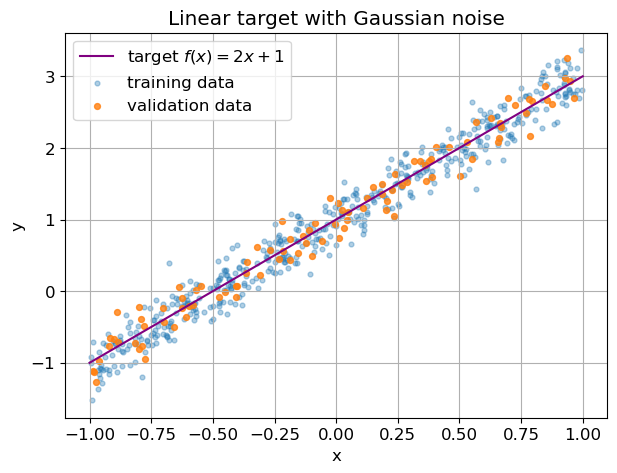

In [4]:
Ntrain = 500
Nvalid = 100
sigma = 0.2

x_train, y_train = generate_1d_data(f_linear, Ntrain, -1, 1, sigma=sigma, seed=1)
x_valid, y_valid = generate_1d_data(f_linear, Nvalid, -1, 1, sigma=sigma, seed=2, sort=True)

x_plot = np.linspace(-1, 1, 300)

plt.figure()
plt.plot(x_plot, f_linear(x_plot), color="purple", label="target $f(x)=2x+1$")
plt.scatter(x_train[:, 0], y_train, s=12, alpha=0.35, label="training data")
plt.scatter(x_valid[:, 0], y_valid, s=18, alpha=0.8, label="validation data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear target with Gaussian noise")
plt.grid(True)
plt.legend()
plt.show()

Alleniamo il modello lineare di riferimento. Poiché la funzione target è lineare, l'unico limite al risultato è il rumore statistico dei dati e il fatto che il training avviene con un numero finito di punti.

E0000 00:00:1783417869.767729 1370914 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


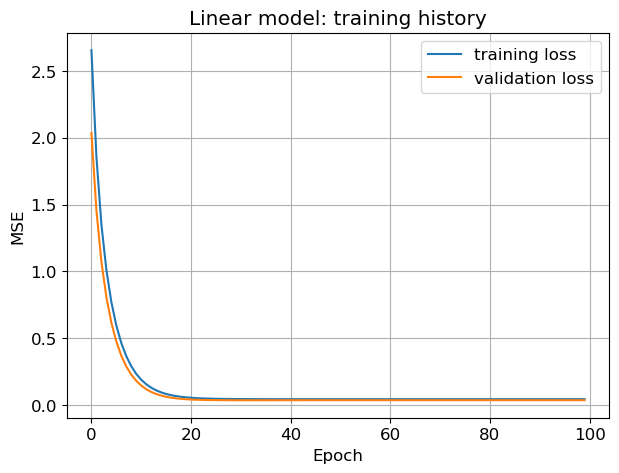

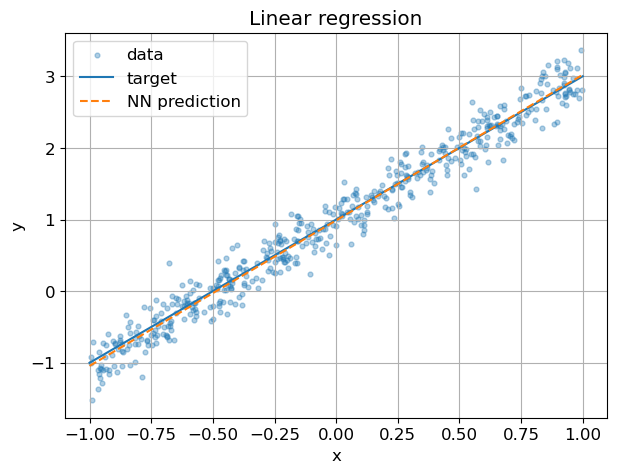

Final training loss:   0.044029
Final validation loss: 0.036626
Learned weight w = 2.0322
Learned bias   b = 0.9885


In [5]:
# Crea il modello lineare definito nella funzione create_linear_model().
model_linear = create_linear_model()

history_linear = model_linear.fit(   

    x_train, y_train,
    epochs=100,
    # Con batch_size=25, la rete aggiorna i parametri dopo aver visto 25 dati.
    batch_size=25,
    # Evita che la rete veda sempre i dati nello stesso ordine.
    shuffle=True,
    validation_data=(x_valid, y_valid),
    verbose=0
)

plot_history(history_linear, "Linear model: training history")


# Disegna il confronto tra training, target e predizione.
plot_1d_prediction(
    model_linear,
    f_linear,
    -1,
    1,
    "Linear regression",
    x_train,
    y_train,
)

# Stampa i valori finali della loss di training e validation.
print_final_losses(history_linear)


# Estrae i parametri imparati dal primo layer del modello.
w, b = model_linear.layers[0].get_weights()

print(f"Learned weight w = {w[0,0]:.4f}")
print(f"Learned bias   b = {b[0]:.4f}")

## Dependence on the number of epochs

Aumentando $N_{\mathrm{epochs}}$ la rete ha più occasioni per aggiornare i pesi. Ci aspettiamo quindi una diminuzione della loss, almeno fino a saturazione. Manteniamo fissati $N_{\mathrm{train}}=500$ e $\sigma=0.2$.

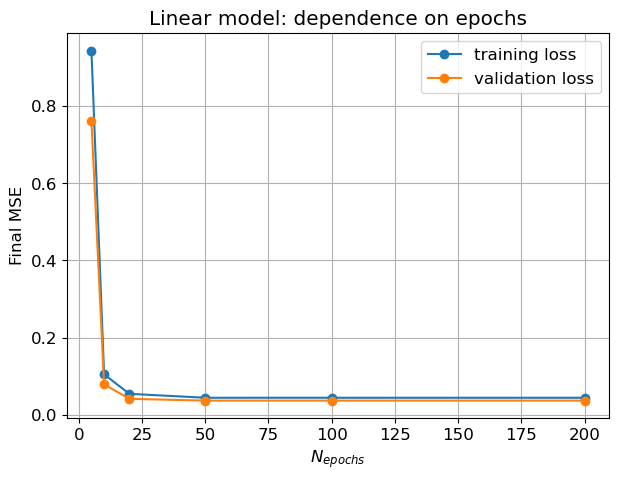

,Nepochs,training_loss,validation_loss
0,5,0.944233,0.761023
1,10,0.104681,0.078670
2,20,0.054232,0.041275
3,50,0.044034,0.036566
4,100,0.044029,0.036626
5,200,0.044029,0.036626


In [6]:
epochs_list = [5, 10, 20, 50, 100, 200]
train_losses = []
valid_losses = []

for n_epochs in epochs_list:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    model = create_linear_model()
    history = model.fit(
        x_train, y_train,
        epochs=n_epochs,
        batch_size=25,
        shuffle=True,
        validation_data=(x_valid, y_valid),
        verbose=0
    )
    train_losses.append(history.history["loss"][-1])
    valid_losses.append(history.history["val_loss"][-1])

plt.figure()
plt.plot(epochs_list, train_losses, "o-", label="training loss")
plt.plot(epochs_list, valid_losses, "o-", label="validation loss")
plt.xlabel("$N_{epochs}$")
plt.ylabel("Final MSE")
plt.title("Linear model: dependence on epochs")
plt.grid(True)
plt.legend()
plt.show()

pd.DataFrame({
    "Nepochs": epochs_list,
    "training_loss": train_losses,
    "validation_loss": valid_losses
})

Per poche epoche il modello può non avere ancora raggiunto i valori ottimali di peso e bias. Aumentando il numero di epoche la loss diminuisce, ma dopo un certo punto il miglioramento diventa piccolo: il modello ha già imparato la struttura lineare dei dati.

## Dipendenza dal numero di dati di training

Ora fissiamo $N_{\mathrm{epochs}}=100$ e $\sigma=0.2$, variamo invece il numero di dati di training. Con pochi dati la stima della retta è più sensibile alle fluttuazioni statistiche; con più dati la rete vede meglio la struttura media $2x+1$.

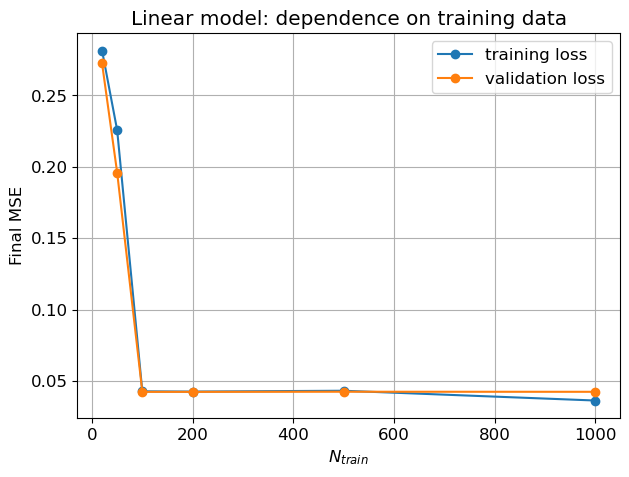

,Ntrain,training_loss,validation_loss
0,20,0.281332,0.272331
1,50,0.225611,0.195906
2,100,0.042813,0.042447
3,200,0.042643,0.042445
4,500,0.043228,0.042539
5,1000,0.036384,0.042483


In [7]:
Ntrain_list = [20, 50, 100, 200, 500, 1000]
train_losses = []
valid_losses = []

Nepochs = 100
sigma = 0.2

x_valid_ref, y_valid_ref = generate_1d_data(f_linear, 300, -1, 1, sigma=sigma, seed=20, sort=True)

for i, n_train in enumerate(Ntrain_list):
    x_tr, y_tr = generate_1d_data(f_linear, n_train, -1, 1, sigma=sigma, seed=100+i)
    model = create_linear_model()
    history = model.fit(
        x_tr, y_tr,
        epochs=Nepochs,
        batch_size=25,
        shuffle=True,
        validation_data=(x_valid_ref, y_valid_ref),
        verbose=0
    )
    train_losses.append(history.history["loss"][-1])
    valid_losses.append(history.history["val_loss"][-1])

plt.figure()
plt.plot(Ntrain_list, train_losses, "o-", label="training loss")
plt.plot(Ntrain_list, valid_losses, "o-", label="validation loss")
plt.xlabel("$N_{train}$")
plt.ylabel("Final MSE")
plt.title("Linear model: dependence on training data")
plt.grid(True)
plt.legend()
plt.show()

pd.DataFrame({
    "Ntrain": Ntrain_list,
    "training_loss": train_losses,
    "validation_loss": valid_losses
})

In generale, aumentando $N_{\mathrm{train}}$ la validation loss diventa più stabile. La training loss può non diminuire monotonicamente, perché è calcolata su dataset diversi e rumorosi; non bisogna quindi interpretare ogni oscillazione come un effetto fisico. Il punto importante è che più dati permettono una stima più robusta della retta sottostante.

## Dipendenza dal rumore $\sigma$

Infine fissiamo $N_{\mathrm{train}}=500$ e $N_{\mathrm{epochs}}=100$, variando la deviazione standard del rumore. Poiché la loss è calcolata sui dati rumorosi, ci aspettiamo che cresca al crescere di $\sigma$.

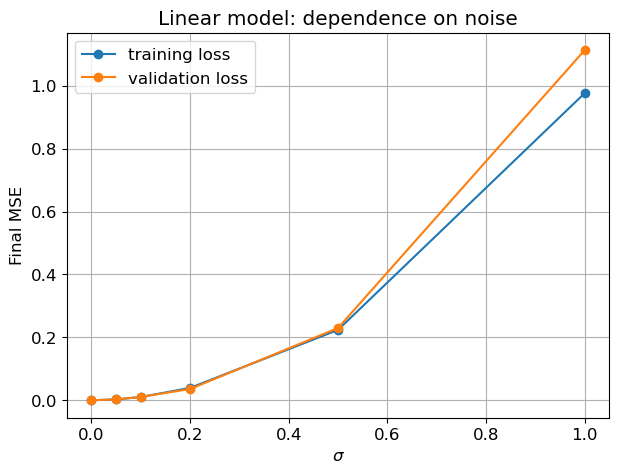

,sigma,training_loss,validation_loss
0,0.00,1.790441e-11,1.969061e-11
1,0.05,2.526755e-03,2.388821e-03
2,0.10,1.022255e-02,1.048442e-02
3,0.20,3.913720e-02,3.560670e-02
4,0.50,2.237031e-01,2.296143e-01
5,1.00,9.762819e-01,1.113102e+00


In [8]:
sigma_list = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]

train_losses = []
valid_losses = []

Ntrain = 500

Nvalid = 300

Nepochs = 100

for i, sigma in enumerate(sigma_list):
    
    # Genera i dati di training rumorosi
    x_tr, y_tr = generate_1d_data(
        f_linear,
        Ntrain,
        -1,
        1,
        sigma=sigma,
        seed=200+i
    )
    
    # Genera i dati di validazione con lo stesso livello di rumore.
    x_va, y_va = generate_1d_data(
        f_linear,
        Nvalid,
        -1,
        1,
        sigma=sigma,
        seed=300+i,
        sort=True
    )

    # Crea un nuovo modello lineare da zero.
    model = create_linear_model()
    
    # Allena il modello sui dati con il rumore corrente.
    history = model.fit(
        x_tr, y_tr,
        epochs=Nepochs,
        batch_size=25,
        shuffle=True,
        validation_data=(x_va, y_va),
        verbose=0
    )
    
    # Salva l'ultimo valore della training loss.
    train_losses.append(history.history["loss"][-1])
    
    # Salva l'ultimo valore della validation loss.
    valid_losses.append(history.history["val_loss"][-1])


plt.figure()
plt.plot(sigma_list, train_losses, "o-", label="training loss")
plt.plot(sigma_list, valid_losses, "o-", label="validation loss")
plt.xlabel(r"$\sigma$")
plt.ylabel("Final MSE")
plt.title("Linear model: dependence on noise")
plt.grid(True)
plt.legend()
plt.show()

pd.DataFrame({
    "sigma": sigma_list,
    "training_loss": train_losses,
    "validation_loss": valid_losses
})

La crescita della loss con $\sigma$ non significa che il modello lineare sia sbagliato: anche la migliore retta possibile non può eliminare il rumore casuale presente nei dati. Il modello deve imparare la tendenza media, non riprodurre esattamente ogni punto rumoroso.

### Commento esercizio 11.1

Nel caso lineare, un solo neurone senza attivazione non lineare è il modello corretto. Aumentare il numero di epoche aiuta fino alla convergenza; aumentare il numero di dati riduce le fluttuazioni statistiche; aumentare il rumore aumenta la loss minima osservabile. Non serve una rete più profonda, perché la funzione target è già lineare.

# Esercizio 11.2 - Regressione polinomiale

La funzione target è ora

$$
f(x)=4-3x-2x^2+3x^3,
$$

con $x\in[-1,1]$. Questa funzione non è lineare, quindi un singolo neurone lineare non è sufficiente. Usiamo una rete feed-forward con layer nascosti e attivazioni non lineari.

La consegna chiede di scegliere in modo ragionato:

- numero di layer;
- numero di neuroni per layer;
- funzione di attivazione;
- ottimizzatore;
- funzione di loss.

Non faremo una grid search estesa: confrontiamo pochi modelli rappresentativi e scegliamo una configurazione semplice e ragionevole.

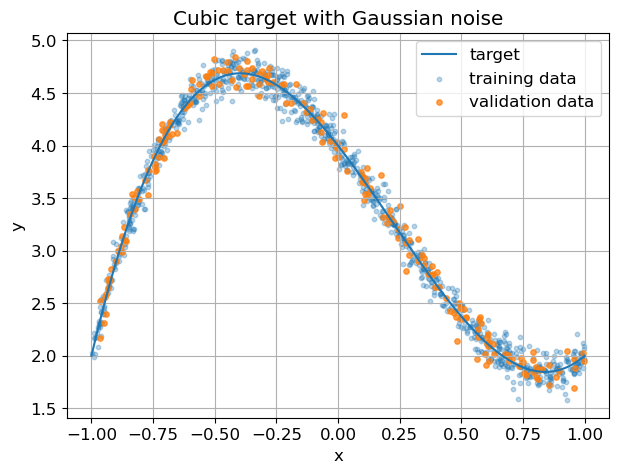

In [9]:
def f_poly(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

Ntrain = 1000
Nvalid = 200
sigma = 0.1

x_train_poly, y_train_poly = generate_1d_data(f_poly, Ntrain, -1, 1, sigma=sigma, seed=10)
x_valid_poly, y_valid_poly = generate_1d_data(f_poly, Nvalid, -1, 1, sigma=sigma, seed=11, sort=True)

x_plot = np.linspace(-1, 1, 400)

plt.figure()
plt.plot(x_plot, f_poly(x_plot), label="target")
plt.scatter(x_train_poly[:, 0], y_train_poly, s=10, alpha=0.30, label="training data")
plt.scatter(x_valid_poly[:, 0], y_valid_poly, s=15, alpha=0.75, label="validation data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic target with Gaussian noise")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
def create_1d_nn(
    n_hidden_layers=2,
    n_neurons=30,
    activation="tanh",
    optimizer="adam",
    loss="mse"
):
    tf.keras.backend.clear_session()
    
    # Crea un modello sequenziale.
    # input -> layer nascosti -> output.
    model = keras.Sequential()
    
    # shape=(1,) significa che ogni dato di input è composto da un solo numero: x.
    model.add(layers.Input(shape=(1,)))

    # Ogni layer contiene n_neurons neuroni.
    for _ in range(n_hidden_layers):
        model.add(layers.Dense(n_neurons, activation=activation))

    # Aggiunge il layer di output.
    model.add(layers.Dense(1))
    

    model.compile(optimizer=optimizer, loss=loss, metrics=["mse"])

    return model

Confrontiamo cinque scelte. Il primo modello è volutamente lineare e serve come baseline. Gli altri introducono non linearità e complessità crescente.

In [11]:
# Lista di configurazioni da confrontare.
configs = [
    {
        "name": "linear baseline",
        "layers": 0,
        "neurons": 0,
        "activation": "linear",
        "optimizer": "sgd"
    },
    {
        "name": "1 layer, relu",
        "layers": 1,
        "neurons": 10,
        "activation": "relu",
        "optimizer": "adam"
    },
    {
        "name": "2 layers, tanh",
        "layers": 2,
        "neurons": 20,
        "activation": "tanh",
        "optimizer": "adam"
    },
    {
        "name": "3 layers, relu",
        "layers": 3,
        "neurons": 50,
        "activation": "relu",
        "optimizer": "adam"
    },
     {
        "name": "4 layers, tanh",
        "layers": 4,
        "neurons": 100,
        "activation": "tanh",
        "optimizer": "adam"
    },
]


# Lista in cui salveremo i risultati numerici finali
comparison = []

# Dizionario in cui salveremo i modelli allenati e le rispettive history.
trained_models = {}

# Ciclo su tutte le configurazioni definite sopra.
for config in configs:

    
    # Caso particolare: modello lineare di riferimento.
    if config["layers"] == 0:
        model = create_1d_nn(
            n_hidden_layers=0,
            n_neurons=1,
            activation="linear",
            optimizer=config["optimizer"],
            loss="mse"
        )
    
    # Caso generale: modello con uno o più layer nascosti.
    else:
        model = create_1d_nn(
            n_hidden_layers=config["layers"],
            n_neurons=config["neurons"],
            activation = config["activation"],
            optimizer=config["optimizer"],
            loss="mse"
        )

    # Allenamento del modello corrente sui dati della funzione polinomiale.
    history = model.fit(
        
        x_train_poly, y_train_poly,
        epochs=250,
        batch_size=25,
        shuffle=True,
        validation_data=(x_valid_poly, y_valid_poly),
        verbose=0
    )

    # Salva in lista i risultati principali del modello corrente.
    comparison.append({
        

        "model": config["name"],
        "hidden_layers": config["layers"],
        "neurons_per_layer": config["neurons"],
        "activation": config["activation"],
        "optimizer": config["optimizer"],
        
        # Numero totale di parametri allenabili del modello.
        "parameters": model.count_params(),
        
        "training_loss": history.history["loss"][-1],
        "validation_loss": history.history["val_loss"][-1]
    })

    # Salva il modello allenato e la sua history.
    trained_models[config["name"]] = (model, history)


# Converte la lista dei risultati in una una tabella e leggibile.
comparison_df = pd.DataFrame(comparison)
comparison_df

,model,hidden_layers,neurons_per_layer,activation,optimizer,parameters,training_loss,validation_loss
0,linear baseline,0,0,linear,sgd,2,0.568249,0.580334
1,"1 layer, relu",1,10,relu,adam,31,0.035249,0.032547
2,"2 layers, tanh",2,20,tanh,adam,481,0.010800,0.011190
3,"3 layers, relu",3,50,relu,adam,5251,0.011299,0.011526
4,"4 layers, tanh",4,100,tanh,adam,30601,0.012103,0.011537


Una scelta ragionevole è il modello con due layer nascosti da 20 neuroni e attivazione `tanh`. È abbastanza flessibile da descrivere una funzione cubica, ma non è inutilmente grande. Usiamo `adam` perché converge in modo più stabile di `sgd` in questo caso, e manteniamo la loss `mse`, coerente con un problema di regressione con rumore gaussiano.

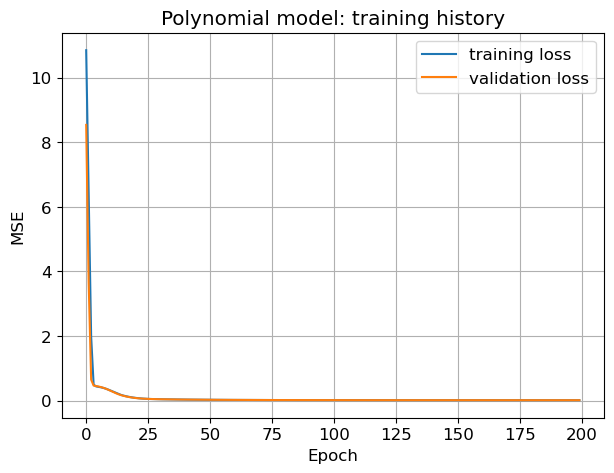

Final training loss:   0.010747
Final validation loss: 0.011002
Number of trainable parameters: 481


In [12]:
model_poly = create_1d_nn(
    n_hidden_layers=2,
    n_neurons=20,
    activation="tanh",
    optimizer="adam",
    loss="mse"
)

history_poly = model_poly.fit(
    x_train_poly, y_train_poly,
    epochs=200,
    batch_size=25,
    shuffle=True,
    validation_data=(x_valid_poly, y_valid_poly),
    verbose=0
)

plot_history(history_poly, "Polynomial model: training history")
print_final_losses(history_poly)
print(f"Number of trainable parameters: {model_poly.count_params()}")

Controlliamo prima la predizione nel range di training $[-1,1]$.

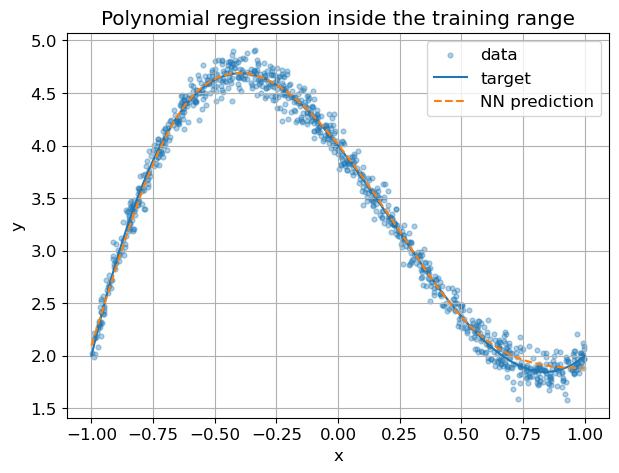

In [13]:
plot_1d_prediction(
    model_poly,
    f_poly,
    -1, 1,
    "Polynomial regression inside the training range",
    x_train_poly,
    y_train_poly
)

Nel range in cui sono presenti dati di training, la rete dovrebbe seguire bene la funzione cubica. La validation loss è il controllo più importante: se training loss e validation loss sono simili, non c'è evidenza forte di overfitting.

Ora controlliamo cosa succede fuori dal range di training, ad esempio in $[-2,2]$.

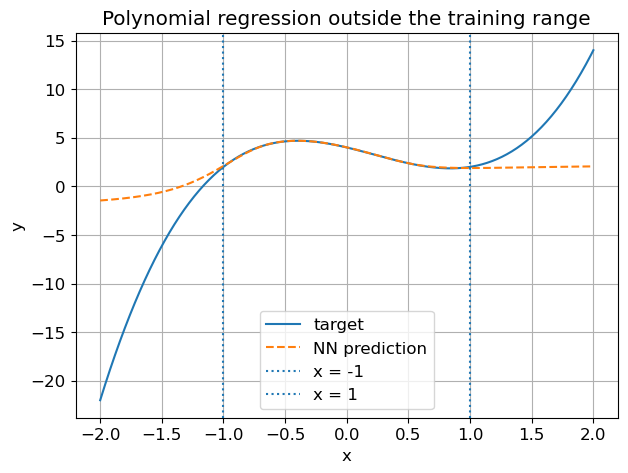

In [14]:
plot_1d_prediction(
    model_poly,
    f_poly,
    -2, 2,
    "Polynomial regression outside the training range",
    vertical_lines=[-1,1]
)

Fuori dal range $[-1,1]$ la rete non ha visto dati. Per questo motivo non bisogna aspettarsi una buona estrapolazione. Anche se il fit è buono nella regione di training, la previsione esterna può allontanarsi rapidamente dalla funzione target. Questo è un punto concettuale importante: una rete neurale è molto efficace in interpolazione, ma l'estrapolazione non è garantita.

### Commento esercizio 11.2

Per la funzione cubica serve una rete non lineare. Una configurazione ragionevole può essere:

- 2 hidden layers;
- 20 neuroni per layer;
- attivazione `tanh`;
- ottimizzatore `adam`;
- loss `mse`.

Aumentare la complessità del modello può migliorare la training loss, ma non è automaticamente un vantaggio: bisogna controllare anche la validation loss. La rete scelta interpola bene nel range di training, mentre fuori da tale range la qualità della previsione non è garantita.

# Esercizio 11.3 - Regressione bidimensionale

Estendiamo ora il problema alla funzione

$$
f(x,y)=\sin(x^2+y^2),
$$

nel dominio

$$
x,y\in[-3/2,3/2].
$$

L'input della rete non è più un singolo numero $x$, ma una coppia $(x,y)$. Per questo motivo il layer di input deve avere forma `Input(shape=(2,))`.

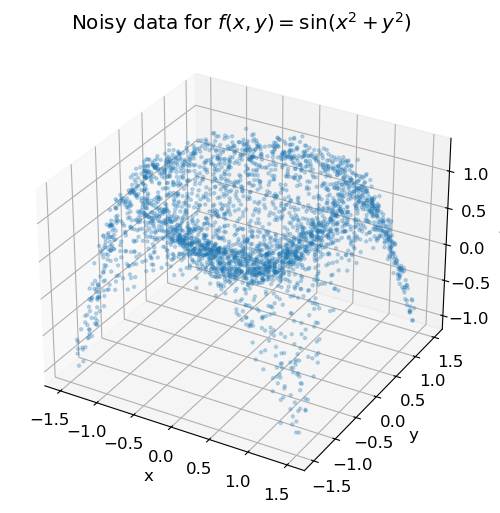

In [15]:
def f_2d(x, y):
    return np.sin(x**2 + y**2)

Ntrain = 3000
Nvalid = 600
sigma = 0.1

rng = np.random.default_rng(30)
xy_train_2d = rng.uniform(-1.5, 1.5, size=(Ntrain, 2))
z_train_2d = f_2d(xy_train_2d[:, 0], xy_train_2d[:, 1]) + rng.normal(0.0, sigma, Ntrain)

rng = np.random.default_rng(31)
xy_valid_2d = rng.uniform(-1.5, 1.5, size=(Nvalid, 2))
z_valid_2d = f_2d(xy_valid_2d[:, 0], xy_valid_2d[:, 1]) + rng.normal(0.0, sigma, Nvalid)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xy_train_2d[:, 0], xy_train_2d[:, 1], z_train_2d, s=5, alpha=0.25, label="training data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Noisy data for $f(x,y)=\\sin(x^2+y^2)$")
plt.show()

In [16]:
def create_2d_nn(n_hidden_layers=2, n_neurons=50, activation="tanh", optimizer="adam", loss="mse"):
    tf.keras.backend.clear_session()
    model = keras.Sequential()
    model.add(layers.Input(shape=(2,)))

    for _ in range(n_hidden_layers):
        model.add(layers.Dense(n_neurons, activation=activation))

    model.add(layers.Dense(1))
    model.compile(optimizer=optimizer, loss=loss, metrics=["mse"])
    return model

Usiamo una rete leggermente più larga rispetto al caso 1D, perché la funzione dipende da due variabili. La scelta resta comunque contenuta: due layer nascosti da 50 neuroni, attivazione `tanh`, optimizer `adam` e loss `mse`.

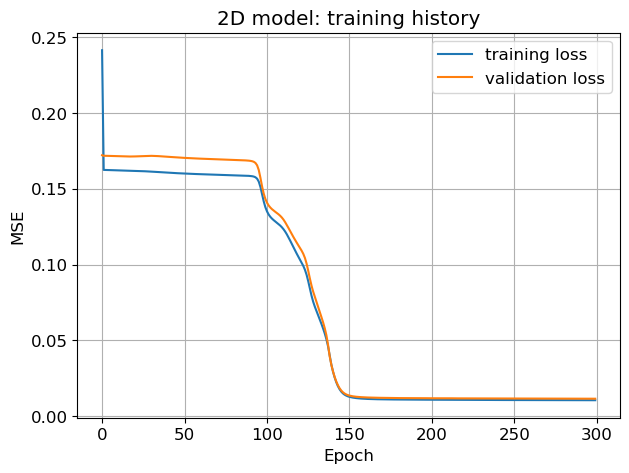

Final training loss:   0.010442
Final validation loss: 0.011438
Number of trainable parameters: 2751


In [17]:
model_2d = create_2d_nn(
    n_hidden_layers=2,
    n_neurons=50,
    activation="tanh",
    optimizer="adam",
    loss="mse"
)

history_2d = model_2d.fit(
    xy_train_2d, z_train_2d,
    epochs=300,
    batch_size=50,
    shuffle=True,
    validation_data=(xy_valid_2d, z_valid_2d),
    verbose=0
)

plot_history(history_2d, "2D model: training history")
print_final_losses(history_2d)
print(f"Number of trainable parameters: {model_2d.count_params()}")

Confrontiamo la superficie target e la superficie predetta dalla rete su una griglia regolare nel dominio di training.

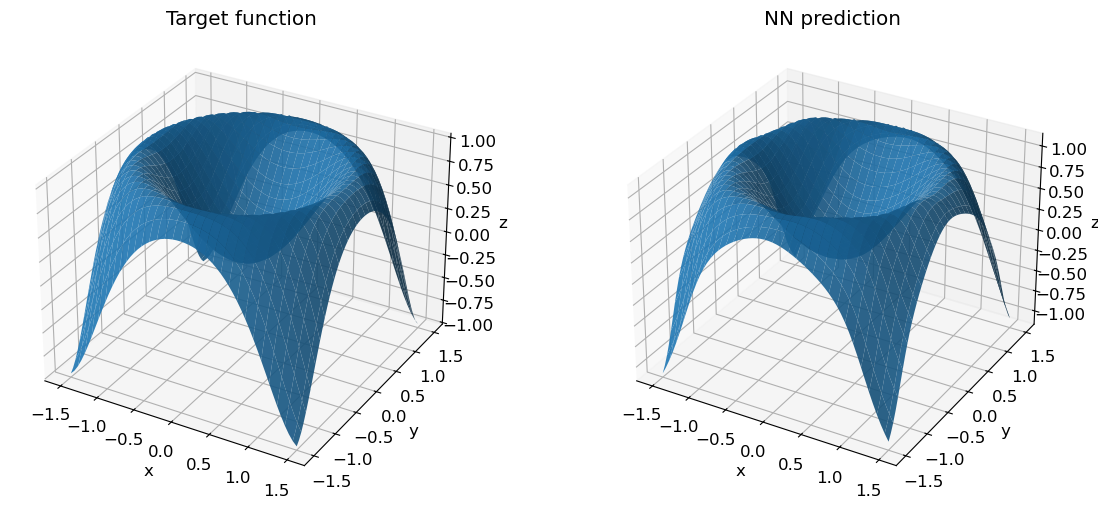

In [18]:
grid = np.linspace(-1.5, 1.5, 60)

# Costruisce una griglia bidimensionale a partire dai valori di grid.
Xg, Yg = np.meshgrid(grid, grid)

# Converte la griglia bidimensionale in una lista di punti.
# Ogni riga di points è una coppia (x, y).
# Questa forma è necessaria per passare i punti alla rete neurale.
points = np.column_stack([Xg.ravel(), Yg.ravel()])

Z_target = f_2d(Xg, Yg)

# Calcola la predizione della rete sui punti della griglia.
Z_pred = model_2d.predict(points, verbose=0).reshape(Xg.shape)

fig = plt.figure(figsize=(14, 6))

# 121 significa: 1 riga, 2 colonne, primo grafico.
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(Xg, Yg, Z_target, linewidth=0, antialiased=True, alpha=0.9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Target function")

# 122 significa: 1 riga, 2 colonne, secondo grafico.
ax = fig.add_subplot(122, projection="3d")
ax.plot_surface(Xg, Yg, Z_pred, linewidth=0, antialiased=True, alpha=0.9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("NN prediction")

plt.show()

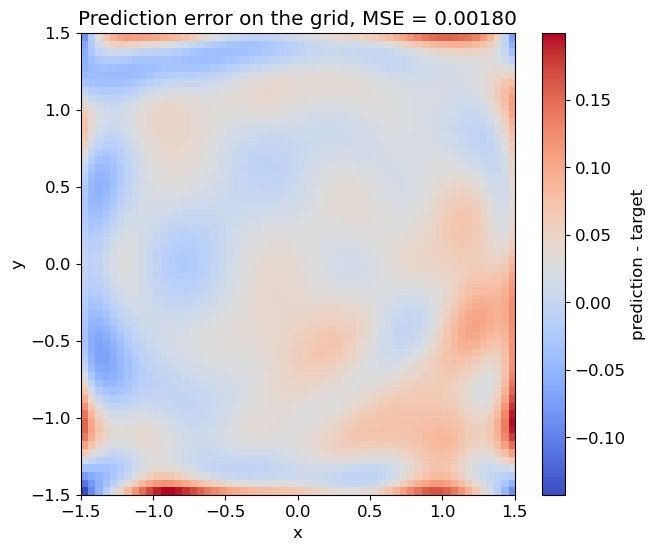

In [19]:
Z_error = Z_pred - Z_target

mse_grid = np.mean(Z_error**2)

plt.figure(figsize=(7, 6))

plt.imshow(
    Z_error,
    

    extent=[-1.5, 1.5, -1.5, 1.5],
    
    # In questo modo l'asse y cresce verso l'alto, come in un normale piano cartesiano.
    origin="lower",
    
    # Lascia che Matplotlib adatti il rapporto tra gli assi alla figura.
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="prediction - target")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Prediction error on the grid, MSE = {mse_grid:.5f}")
plt.show()

La rete riesce ad approssimare la struttura radiale della funzione $\sin(x^2+y^2)$ nel dominio in cui è stata allenata. Anche qui il confronto tra training loss e validation loss è essenziale: se sono vicine, il modello non sta semplicemente memorizzando i dati di training. La mappa dell'errore serve a vedere in quali zone del dominio la predizione è meno accurata.

# Conclusioni finali

L'esercizio mostra tre livelli crescenti di complessità.

Nel caso lineare, un singolo neurone è sufficiente perché la funzione target è della forma $wx+b$. In questo caso aumentare la complessità della rete non è necessario.

Nel caso cubico, una rete lineare non basta: servono hidden layer con attivazioni non lineari. Una rete moderatamente complessa interpola bene nel range di training, ma non garantisce buone previsioni fuori da tale intervallo.

Nel caso bidimensionale, l'input passa da uno a due valori e la rete deve imparare una superficie. Una rete leggermente più larga permette di ottenere un fit ragionevole senza introdurre una ricerca eccessiva degli iperparametri.

La lezione generale è che la bontà di una rete non si giudica solo dalla training loss. Bisogna confrontare training e validation loss e distinguere tra interpolazione, dove la rete può funzionare bene, ed estrapolazione, dove non ci sono garanzie.